In [2]:
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv(r"E:\B.Tech IIT Dh\Sem 2\Machine Learning\Mall Customer Segmention\Mall_Customers.csv")

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
from sklearn.preprocessing import StandardScaler


In [14]:
df['Gender'] = df['Gender'].map({'Male' : 0, 'Female' : 1 })

In [18]:
scaler = StandardScaler()
featuers = ['Age', 'Gender','Annual Income (k$)', 'Spending Score (1-100)' ]
x = df[featuers]
X_scaled = scaler.fit_transform(x)

In [17]:
X_scaled

array([[-1.42456879, -1.12815215, -1.73899919, -0.43480148],
       [-1.28103541, -1.12815215, -1.73899919,  1.19570407],
       [-1.3528021 ,  0.88640526, -1.70082976, -1.71591298],
       [-1.13750203,  0.88640526, -1.70082976,  1.04041783],
       [-0.56336851,  0.88640526, -1.66266033, -0.39597992],
       [-1.20926872,  0.88640526, -1.66266033,  1.00159627],
       [-0.27630176,  0.88640526, -1.62449091, -1.71591298],
       [-1.13750203,  0.88640526, -1.62449091,  1.70038436],
       [ 1.80493225, -1.12815215, -1.58632148, -1.83237767],
       [-0.6351352 ,  0.88640526, -1.58632148,  0.84631002],
       [ 2.02023231, -1.12815215, -1.58632148, -1.4053405 ],
       [-0.27630176,  0.88640526, -1.58632148,  1.89449216],
       [ 1.37433211,  0.88640526, -1.54815205, -1.36651894],
       [-1.06573534,  0.88640526, -1.54815205,  1.04041783],
       [-0.13276838, -1.12815215, -1.54815205, -1.44416206],
       [-1.20926872, -1.12815215, -1.54815205,  1.11806095],
       [-0.27630176,  0.

In [20]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Spending Score (1-100)')

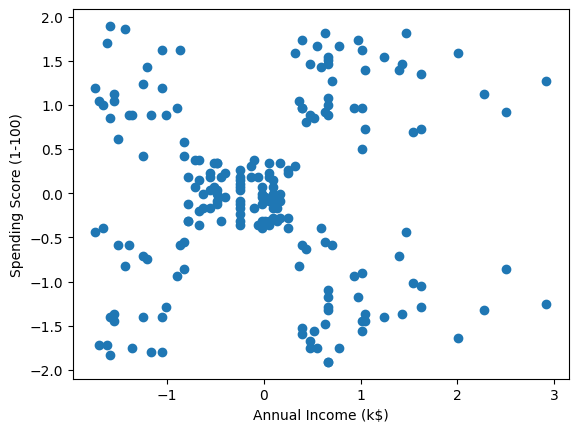

In [27]:
plt.scatter(
    X_scaled[ : , 2], 
    X_scaled[ : , 3]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

In [32]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=4).fit(X_scaled)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 12
Estimated number of noise points: 76


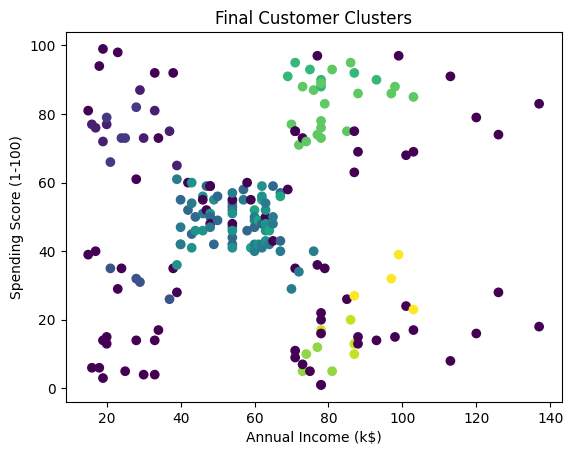

In [35]:
plt.scatter(
    df['Annual Income (k$)'], 
    df['Spending Score (1-100)'], 
    c=labels
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Final Customer Clusters")

plt.show()